# Rede Neural (MLP) — Previsão de Churn (Telco)

**Autor:** Alessandro Stefani  
**Data:** 2026-06-24  
**Disciplina:** Tech Challenge — Fase 01 (Produtização de Modelos)  
**Etapa:** 2 — Modelagem com Rede Neural  
**Descrição:** Engenharia de features, construção e treinamento de uma MLP em PyTorch para previsão de churn, com comparação frente aos baselines (Notebook 01) e rastreamento no MLflow.

**Dataset:** TelcoCustomerChurn.csv  
**Pré-requisito:** decisões de seleção de features e exclusão de leakage definidas no Notebook 01 (incluindo a remoção de `SatisfactionScore`).

## 1. Setup e imports

Imports e constantes globais (`SEED`, `device`, caminho do dataset).

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import copy
import mlflow
import mlflow.pytorch
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt


dataset_path = "../data/raw/TelcoCustomerChurn.csv"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)        # seed do PyTorch


if torch.cuda.is_available():
    device = torch.device("cuda")        # Ubuntu / RTX 5070
elif torch.backends.mps.is_available():
    device = torch.device("mps")         # Mac / Apple GPU
else:
    device = torch.device("cpu")         # CPU (funciona em ambos)

#device = torch.device("cpu")            # Mac roda mais rápido em CPU. Estudar motivo posteriormente
print("device:", device)

## 2. Carregamento e seleção de features

Carregar o dataset bruto e aplicar as decisões do Notebook 01: drops (id, leakage, redundância, constantes, alta cardinalidade + `SatisfactionScore`), imputação de negócio (Offer, InternetType) e mapeamento do alvo.

In [2]:
df = pd.read_csv(dataset_path)

print(df.shape)

# imputação de negócio (constante → leakage-safe)
df["Offer"] = df["Offer"].fillna("No offer")
df["InternetType"] = df["InternetType"].fillna("No internet")

y = df["ChurnLabel"].map({"No": 0, "Yes": 1})

USAR_GEO = True   # ⚑ A/B: Lat/Long (inertes no baseline linear; testar se a MLP extrai)

COLS_DROP = [
    "ChurnLabel", "CustomerID",
    "CustomerStatus", "ChurnScore", "ChurnCategory", "ChurnReason",   # leakage
    "CLTV",
    "ZipCode", "SeniorCitizen", "Under30", "TotalRevenue", "InternetService",
    "Country", "State", "Quarter", "City",
    "SatisfactionScore",                       # leakage confirmado
    "Dependents", "ReferredaFriend",           # flags colineares → usar as contínuas
]
if not USAR_GEO:
    COLS_DROP += ["Latitude", "Longitude"]

X = df.drop(columns=COLS_DROP)
print(X.shape)


(7043, 50)
(7043, 31)


## 3. Engenharia de features

Criação de novas variáveis a partir das existentes (ex.: razões, agregações, faixas/bins, interações). Documentar a hipótese de negócio por trás de cada feature criada.

> **A preencher:** features planejadas e a justificativa de cada uma.

In [3]:
# feature nova: valor médio histórico da fatura (razão, não soma → não redundante)
X["valor_medio_fatura"] = X["TotalCharges"] / X["TenureinMonths"]   # tenure min=1, sem div/0

USAR_CONTAGENS = False   # ⚑ A/B: contagens como viés indutivo (binários ABERTOS mantidos)

if USAR_CONTAGENS:
    sim = lambda c: X[c].eq("Yes").astype(int)
    X["qtd_adicionais"] = (sim("OnlineSecurity") + sim("OnlineBackup")
                           + sim("DeviceProtectionPlan") + sim("PremiumTechSupport"))  # coerente ✓
    X["qtd_streaming"]  = sim("StreamingTV") + sim("StreamingMovies") + sim("StreamingMusic")  # fraca
    X["qtd_principais"] = sim("PhoneService") + X["InternetType"].ne("No internet").astype(int)  # pior (apaga internet)

print(X.shape)

(7043, 32)


## 4. Pré-processamento e split

Mesma base do Notebook 01: `log1p` nas skewed, one-hot nas categóricas, splits estratificados (`SEED=42`) e `StandardScaler` ajustado **só no treino**.  
**64% - treino**  
**16% - val**  
**20% - teste**

In [4]:
# log1p nas skewed - Esse tratamento ajusta os valores com base neles mesmo, então pode (e deve) ser aplicado antes do slit
skewed = ["TotalLongDistanceCharges", "AvgMonthlyGBDownload"]
X[skewed] = np.log1p(X[skewed])

# Lista de colunas numéricas e de texto para aplicar nos tratamentos posteriores
num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes("object").columns.tolist()

# Split 1: separa 20% para amostra de teste — idêntico ao NB01 (mesmo SEED/stratify)
X_dev, X_te, y_dev, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# Split 2: separa amostra para validação (usada no early stopping) dos 80% restantes
# treino 64%
# val    16%
# teste  20%
X_tr, X_val, y_tr, y_val = train_test_split(X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=SEED)


# OneHotEncoder e StandardScaler apenas na amostra de treino, para o modelo não "ver" dados diferentes dos utilizados no treinamento
# handle_unknown="ignore" garante colunas consistentes para 1 ou N registros — o
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
scaler = StandardScaler()
ohe.fit(X_tr[cat_cols])
scaler.fit(X_tr[num_cols])

cat_names = ohe.get_feature_names_out(cat_cols)


def preparar(parte):
    """Aplica o MESMO pré-processamento ajustado no treino. Retorna DataFrame."""
    num = pd.DataFrame(scaler.transform(parte[num_cols]), columns=num_cols, index=parte.index)
    cat = pd.DataFrame(ohe.transform(parte[cat_cols]), columns=cat_names, index=parte.index)
    return pd.concat([num, cat], axis=1)


X_tr  = preparar(X_tr)
X_val = preparar(X_val)
X_te  = preparar(X_te)


# Criantdo os tensores na memória do device
def to_tensor(Xdf, ys):
    return (torch.tensor(Xdf.astype(np.float32).values, device=device),
            torch.tensor(ys.values, dtype=torch.float32, device=device).unsqueeze(1))

Xtr_t,  ytr_t  = to_tensor(X_tr,  y_tr)
Xval_t, yval_t = to_tensor(X_val, y_val)
Xte_t,  yte_t  = to_tensor(X_te,  y_te)

print("treino:", tuple(Xtr_t.shape), "| val:", tuple(Xval_t.shape),
      "| teste:", tuple(Xte_t.shape), "| device:", Xtr_t.device)

treino: (4507, 40) | val: (1127, 40) | teste: (1409, 40) | device: cuda:0


## 5. Modelo MLP (PyTorch)

Definição da arquitetura (camadas, ativação, dropout/regularização), função de perda (atentar ao desbalanceamento — ex.: `pos_weight` no BCE) e otimizador.

In [5]:
# pos_weight para aplicação posterior na análise de loss (ajuste nos erros por dataset desbalanceado)
pos_weight = torch.tensor([float((y_tr == 0).sum() / (y_tr == 1).sum())], device=device)


class MLP(nn.Module):
    """Arquitetura: blocos Linear -> ReLU -> Dropout; saída em 1 logit (BCEWithLogits)."""
    def __init__(self, in_dim, hidden, dropout):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]              # saída em logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("MLP e loss definidos. pos_weight =", round(pos_weight.item(), 2))

MLP e loss definidos. pos_weight = 2.77


## 6. Funções de treinamento e avaliação

Definição da arquitetura de treino: hiperparâmetros default (`CONFIG`), loop de treino com mini-batches e early stopping (`treinar_mlp`), cálculo de métricas compatíveis com o NB01 (`metricas`) e função de experimentação que empacota treino + avaliação + log no MLflow (`rodar_experimento`).

> **Nota sobre custo de treinamento:** o dataset é pequeno (7.043 linhas), o que mantém o custo absoluto de treinamento baixo mesmo com uma busca de hiperparâmetros mais ampla. Aproveitamos o hardware disponível (GPU local) para explorar arquiteturas e hiperparâmetros mais agressivos sem impacto relevante de tempo/recurso. Ainda assim, mantemos early stopping e limites sensatos para evitar desperdício — trata-se de um trade-off consciente, não de ausência de preocupação com custo.

In [6]:
# Hiperparâmetros de treino (rede pequena p/ tabular pequeno; ajustáveis)
CONFIG = {"hidden": [64, 32],
          "dropout": 0.3,
          "lr": 1e-3,
          "batch": 256,
          "max_epochs": 200,
          "patience": 20}


def val_pr_auc(model, Xv, yv):
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(Xv)).cpu().numpy().ravel()
    return average_precision_score(yv.cpu().numpy().ravel(), p)


def treinar_mlp(Xtr_t, ytr_t, Xval_t, yval_t, cfg, loss_fn):
    """Loop de treino com batching + early stopping (monitora val PR-AUC).
    Restaura os melhores pesos. Retorna (model, history, best_epoch)."""
    torch.manual_seed(SEED)
    model  = MLP(Xtr_t.shape[1], cfg["hidden"], cfg["dropout"]).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=cfg["batch"], shuffle=True)

    best, history, wait = {"prauc": -1, "state": None, "epoch": 0}, [], 0
    for epoch in range(1, cfg["max_epochs"] + 1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        vp = val_pr_auc(model, Xval_t, yval_t)
        history.append((epoch, loss.item(), vp))
        if vp > best["prauc"]:
            best, wait = {"prauc": vp, "state": copy.deepcopy(model.state_dict()), "epoch": epoch}, 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break
    model.load_state_dict(best["state"])     # restaura o melhor
    return model, history, best["epoch"]


def metricas(model, Xtr_t, ytr_true, Xte_t, yte_true):
    """Mesmo conjunto da logar_metricas do NB01 (comparável)."""
    model.eval()
    with torch.no_grad():
        proba_tr = torch.sigmoid(model(Xtr_t)).cpu().numpy().ravel()
        proba_te = torch.sigmoid(model(Xte_t)).cpu().numpy().ravel()
    pred_tr = (proba_tr >= 0.5).astype(int)
    pred_te = (proba_te >= 0.5).astype(int)
    m = {
        "train_accuracy": accuracy_score(ytr_true, pred_tr),
        "test_accuracy":  accuracy_score(yte_true, pred_te),
        "test_f1_score":  f1_score(yte_true, pred_te),     # <- mesmo nome do NB01
        "test_precision": precision_score(yte_true, pred_te),
        "test_recall":    recall_score(yte_true, pred_te),
        "test_roc_auc":   roc_auc_score(yte_true, proba_te),
        "test_pr_auc":    average_precision_score(yte_true, proba_te),
        "train_pr_auc":   average_precision_score(ytr_true, proba_tr),
    }
    m["overfitting"] = m["train_accuracy"] - m["test_accuracy"]
    m["dif_pr_auc"] = m["train_pr_auc"] - m["test_pr_auc"]
    return m


def rodar_experimento(run_name=None, log_mlflow=True, **overrides):
    """Treina + avalia + (opcional) loga a MLP. Hiperparâmetros via kwargs.

    Usa os tensores já preparados do notebook (Xtr_t, Xval_t, Xte_t).
    Ex.: rodar_experimento(hidden=[128, 64], lr=5e-4, dropout=0.4)
    Qualquer chave não passada usa o default de CONFIG.
    """
    cfg = {**CONFIG, **overrides}                    # overrides em cima do default
    if run_name is None:
        run_name = f"mlp_h{cfg['hidden']}_lr{cfg['lr']}_dp{cfg['dropout']}"

    model, history, best_epoch = treinar_mlp(Xtr_t, ytr_t, Xval_t, yval_t, cfg, loss_fn)
    met = metricas(model, Xtr_t, y_tr.values, Xte_t, y_te.values)

    if log_mlflow:
        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({**cfg, "seed": SEED, "n_features": Xtr_t.shape[1],
                               "usar_geo": USAR_GEO, "usar_contagens": USAR_CONTAGENS,
                               "best_epoch": best_epoch, "dataset": "TelcoCustomerChurn.csv"})
            for epoch, tr_loss, vp in history:
                mlflow.log_metric("train_loss", tr_loss, step=epoch)
                mlflow.log_metric("val_pr_auc", vp, step=epoch)
            mlflow.log_metrics(met)
            ex = X_te.iloc[:5].astype("float32")
            with torch.no_grad():
                out = torch.sigmoid(model(torch.tensor(ex.values, device=device))).cpu().numpy()
            mlflow.pytorch.log_model(model, "model",
                                     signature=infer_signature(ex, out), input_example=ex)

    print(f"{run_name} | best_epoch {best_epoch} | PR-AUC {met['test_pr_auc']:.4f} | recall {met['test_recall']:.4f}")
    
    return model, met

## 7. Validação cruzada estratificada

Antes de explorar hiperparâmetros, estabelecemos a performance dos modelos com validação cruzada estratificada (`StratifiedKFold`, 5 folds) sobre o dev set (80%). Cada fold faz pré-processamento independente (OHE + Scaler ajustados apenas no treino do fold) e reporta métricas no fold de teste — nenhum dado vaza entre folds.

Para a MLP, cada fold faz um sub-split interno (80/20 do fold de treino) para early stopping — o mesmo esquema da Seção 6. Os baselines (LogReg, RF) treinam no mesmo sub-treino para comparação justa. A média ± desvio-padrão de PR-AUC dá uma estimativa robusta de generalização e mostra a sensibilidade à partição. O teste final (20%) permanece intocado para a análise de custo (Seção 9).

In [ ]:
N_SPLITS = 5

modelos_baseline = {
    "LogReg": LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced"),
    "RF": RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                  class_weight="balanced", random_state=SEED, n_jobs=-1),
}


def cv_estratificada(X_raw, y, num_cols, cat_cols, cfg_mlp, n_splits=N_SPLITS):
    """StratifiedKFold CV para MLP + baselines sklearn no mesmo esquema de folds."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    todos = {nome: [] for nome in ["MLP", "LogReg", "RF"]}

    for fold, (idx_dev, idx_te) in enumerate(skf.split(X_raw, y), 1):
        Xf_dev, Xf_te = X_raw.iloc[idx_dev], X_raw.iloc[idx_te]
        yf_dev, yf_te = y.iloc[idx_dev], y.iloc[idx_te]

        # sub-split para early stopping da MLP (80/20 do fold de treino)
        Xf_tr, Xf_val, yf_tr, yf_val = train_test_split(
            Xf_dev, yf_dev, test_size=0.2, stratify=yf_dev, random_state=SEED)

        # OHE + Scaler fit apenas no treino do fold
        ohe_f = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
        scaler_f = StandardScaler()
        ohe_f.fit(Xf_tr[cat_cols])
        scaler_f.fit(Xf_tr[num_cols])
        cat_f = ohe_f.get_feature_names_out(cat_cols)

        def prep(df):
            n = pd.DataFrame(scaler_f.transform(df[num_cols]), columns=num_cols, index=df.index)
            c = pd.DataFrame(ohe_f.transform(df[cat_cols]), columns=cat_f, index=df.index)
            return pd.concat([n, c], axis=1)

        Xtr_p, Xval_p, Xte_p = prep(Xf_tr), prep(Xf_val), prep(Xf_te)

        # ── MLP ──────────────────────────────────────────────────────
        pw = torch.tensor([float((yf_tr == 0).sum() / (yf_tr == 1).sum())], device=device)
        loss_f = nn.BCEWithLogitsLoss(pos_weight=pw)

        def to_t(df, ys):
            return (torch.tensor(df.astype(np.float32).values, device=device),
                    torch.tensor(ys.values, dtype=torch.float32, device=device).unsqueeze(1))

        Xtr_t, ytr_t = to_t(Xtr_p, yf_tr)
        Xval_t, yval_t = to_t(Xval_p, yf_val)
        Xte_t, _ = to_t(Xte_p, yf_te)

        model_f, _, _ = treinar_mlp(Xtr_t, ytr_t, Xval_t, yval_t, cfg_mlp, loss_f)
        todos["MLP"].append(metricas(model_f, Xtr_t, yf_tr.values, Xte_t, yf_te.values))

        # ── Baselines sklearn ────────────────────────────────────────
        for nome, mod_base in modelos_baseline.items():
            m = clone(mod_base)
            m.fit(Xtr_p, yf_tr)
            proba_tr = m.predict_proba(Xtr_p)[:, 1]
            proba_te = m.predict_proba(Xte_p)[:, 1]
            pred_tr = m.predict(Xtr_p)
            pred_te = m.predict(Xte_p)
            met = {
                "train_pr_auc":   average_precision_score(yf_tr, proba_tr),
                "test_pr_auc":    average_precision_score(yf_te, proba_te),
                "test_roc_auc":   roc_auc_score(yf_te, proba_te),
                "test_recall":    recall_score(yf_te, pred_te),
                "test_precision": precision_score(yf_te, pred_te),
                "test_f1_score":  f1_score(yf_te, pred_te),
                "test_accuracy":  accuracy_score(yf_te, pred_te),
                "train_accuracy": accuracy_score(yf_tr, pred_tr),
            }
            met["dif_pr_auc"] = met["train_pr_auc"] - met["test_pr_auc"]
            met["overfitting"] = met["train_accuracy"] - met["test_accuracy"]
            todos[nome].append(met)

        pr = lambda n: f"{todos[n][-1]['test_pr_auc']:.4f}"
        print(f"  Fold {fold}:  MLP {pr('MLP')}  |  LogReg {pr('LogReg')}  |  RF {pr('RF')}")

    return todos


def resumo_cv(todos):
    """Tabela-resumo com média ± std das métricas de cada modelo."""
    metricas_cv = ["test_pr_auc", "dif_pr_auc", "test_roc_auc",
                   "test_recall", "test_precision", "test_f1_score", "test_accuracy"]
    rows = []
    for nome in ["MLP", "LogReg", "RF"]:
        row = {"modelo": nome}
        for m in metricas_cv:
            vals = [f[m] for f in todos[nome]]
            row[f"{m}_mean"] = np.mean(vals)
            row[f"{m}_std"]  = np.std(vals)
        rows.append(row)
    df = pd.DataFrame(rows).set_index("modelo")

    fmt = pd.DataFrame(index=df.index)
    for m in metricas_cv:
        fmt[m] = df.apply(lambda r: f"{r[f'{m}_mean']:.4f} ± {r[f'{m}_std']:.4f}", axis=1)
    return fmt


# ── Execução ─────────────────────────────────────────────────────
print(f"Stratified {N_SPLITS}-Fold CV no dev set ({len(X_dev)} amostras)\n")
resultados_cv = cv_estratificada(X_dev, y_dev, num_cols, cat_cols, cfg_mlp=CONFIG)
print()
display(resumo_cv(resultados_cv))

## 8. Exploração de hiperparâmetros e registro no MLflow

Com a performance-base validada por CV (Seção 7), exploramos variações de hiperparâmetros (batch size, learning rate, profundidade da rede) registrando cada run no MLflow. O objetivo é encontrar a configuração que maximize PR-AUC no split fixo (64/16/20) — a tabela final compara todas as runs, incluindo os baselines do NB01.

In [7]:
EXPERIMENTOS = ["customer_churn_prediction", "telco_churn_mlp"]   # baselines (NB01) + MLP (NB02)
METRICAS = ["train_pr_auc", "test_pr_auc", "dif_pr_auc",
            "test_precision", "test_recall", "test_f1_score",
            "test_accuracy", "train_accuracy", "overfitting",
            "test_roc_auc",]


def comparar_modelos(experimentos=None, metricas=None, filtro=None, ordenar_por="test_pr_auc"):
    experimentos = experimentos or EXPERIMENTOS      # default explícito, sem mutable-default
    metricas = metricas or METRICAS
    runs = mlflow.search_runs(experiment_names=experimentos)
    if runs.empty:
        print("Nenhum run encontrado — rode os notebooks 01 e 02 primeiro.")
        return runs
    runs = runs.sort_values("start_time").drop_duplicates("tags.mlflow.runName", keep="last")

    tab = pd.DataFrame({"modelo": runs["tags.mlflow.runName"].to_numpy()})
    for m in metricas:                                # usa o PARÂMETRO, não a global
        col = f"metrics.{m}"
        tab[m] = runs[col].to_numpy() if col in runs else np.nan
    if "metrics.test_f1" in runs:
        tab["test_f1_score"] = tab["test_f1_score"].fillna(pd.Series(runs["metrics.test_f1"].to_numpy()))

    if filtro is not None:
        cond = tab["modelo"].str.contains(filtro) if isinstance(filtro, str) else tab["modelo"].map(filtro)
        tab = tab[cond]
    return tab.set_index("modelo").sort_values(ordenar_por, ascending=False).round(4)


In [15]:
mlflow.set_experiment("telco_churn_mlp")

#rodar_experimento(log_mlflow=True, run_name="mlp_config_padrao")
#rodar_experimento(batch=128, log_mlflow=True, run_name="mlp_ba128")
#rodar_experimento(hidden=[256, 128, 64], batch=128, log_mlflow=True, run_name="mlp_hi256-128-64")
#rodar_experimento(patience=50, log_mlflow=True, run_name="mlp_pa50")
#rodar_experimento(lr=1e-4, log_mlflow=True, run_name="mlp_lr1e-4")
#rodar_experimento(lr=1e-4, batch=128, log_mlflow=True, run_name="mlp_lr1e-4_ba128")
#rodar_experimento(hidden=[128, 64, 32], batch=128, log_mlflow=True, run_name="mlp_hi128-64-32")
#rodar_experimento(batch=64, log_mlflow=True, run_name="mlp_ba64")
rodar_experimento(lr=1e-4, batch=64, log_mlflow=True, run_name="mlp_lr1e-4_ba64")


#rodar_experimento(hidden=[256, 128, 64], batch=128, log_mlflow=True, run_name="mlp_hi3_ba128")
#rodar_experimento(batch=64, log_mlflow=True, run_name="duas_camadas_64")
#rodar_experimento(batch=128, lr=1e-4, log_mlflow=True, run_name="h2_ba128_lr1e-4")
#rodar_experimento(batch=128, lr=1e-4, max_epochs=500, patience=50, log_mlflow=True, run_name="ba128_lr1e-4_ep500_pa50")


#display(comparar_modelos())
display(comparar_modelos(filtro=lambda n: "com_satisfaction" not in n))

#rodar_experimento(dropout=0.5, lr=5e-4, log_mlflow=False)
#rodar_experimento(hidden=[128, 64], lr=5e-4, run_name="mlp_candidato")  # gostou → loga
#hidden=[64, 32]
#dropout=0.3
#lr=1e-3
#lr=3e-4
#lr=1e-4
#batch=256
#max_epochs=200
#patience=20




2026/06/28 16:54:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/28 16:54:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


mlp_lr1e-4_ba64 | best_epoch 157 | PR-AUC 0.7789 | recall 0.8663


,train_pr_auc,test_pr_auc,dif_pr_auc,test_precision,test_recall,test_f1_score,test_accuracy,train_accuracy,overfitting,test_roc_auc
modelo,,,,,,,,,,
mlp_ba128,0.8421,0.7812,0.0609,0.6008,0.8529,0.7050,0.8105,0.8469,0.0364,0.9099
mlp_lr1e-4_ba128,0.8048,0.7800,0.0248,0.6045,0.8663,0.7121,0.8141,0.8269,0.0129,0.9100
mlp_lr1e-4_ba64,0.8128,0.7789,0.0338,0.6011,0.8663,0.7097,0.8119,0.8336,0.0217,0.9104
mlp_ba64,0.8190,0.7782,0.0408,0.6125,0.8663,0.7176,0.8190,0.8367,0.0177,0.9117
mlp_hi128-64-32,0.8591,0.7778,0.0813,0.5988,0.8342,0.6972,0.8077,0.8598,0.0521,0.9050
mlp_hi256-128-64,0.8772,0.7776,0.0996,0.5925,0.8396,0.6947,0.8041,0.8664,0.0623,0.9047
mlp_pa50,0.8167,0.7761,0.0406,0.5985,0.8770,0.7115,0.8112,0.8307,0.0195,0.9103
mlp_config_padrao,0.8167,0.7761,0.0406,0.5985,0.8770,0.7115,0.8112,0.8307,0.0195,0.9103
mlp_lr1e-4,0.7961,0.7753,0.0208,0.6060,0.8636,0.7122,0.8148,0.8221,0.0073,0.9079


## 9. Análise de trade-off de custo (FP × FN)

Nem todos os erros custam igual. Em churn:
- **FN (churn perdido):** cliente sai sem ação → perda de receita futura
- **FP (alarme falso):** campanha de retenção desnecessária → custo operacional

O threshold padrão (0.5) ignora essa assimetria. Varremos thresholds para encontrar o ponto que **minimiza o custo total** = FP × custo_fp + FN × custo_fn.

**Premissas:** razão FN/FP = 10:1 — cada churn perdido custa ~10× uma campanha desnecessária. Os valores absolutos importam menos que a razão.

Para comparação justa, todos os modelos (MLP, LogReg, RF) são treinados no **mesmo conjunto de treino** (64%) e avaliados no **mesmo teste** (20%), com o mesmo pré-processamento.

In [16]:

# ── Premissas de custo (ajustáveis) ────────────────────────────────
# Razão FN/FP = 10:1 — cada churn perdido custa ~10× uma campanha desnecessária.
# Os valores absolutos importam menos que a razão.
CUSTO_FN = 500   # perder o cliente (receita futura)
CUSTO_FP = 50    # campanha de retenção em quem não ia sair


def custo_por_threshold(y_true, y_proba, custo_fn=CUSTO_FN, custo_fp=CUSTO_FP):
    """Varre thresholds: para cada um, calcula FP, FN e custo total."""
    y_true, y_proba = np.asarray(y_true).ravel(), np.asarray(y_proba).ravel()
    rows = []
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_proba >= t).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        custo = fp * custo_fp + fn * custo_fn
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1v  = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        rows.append({"threshold": round(t, 4), "tp": tp, "fp": fp, "fn": fn,
                      "custo_total": custo, "precision": round(prec, 4),
                      "recall": round(rec, 4), "f1": round(f1v, 4)})
    return pd.DataFrame(rows)


def plotar_custo(df_custo, titulo=""):
    """Custo total × threshold (esq.) + FP vs FN (dir.). Retorna (threshold_ótimo, custo_mínimo)."""
    idx = df_custo["custo_total"].idxmin()
    t_opt, c_opt = df_custo.loc[idx, "threshold"], df_custo.loc[idx, "custo_total"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(df_custo["threshold"], df_custo["custo_total"], lw=2)
    ax1.axvline(t_opt, color="red", ls="--", lw=1)
    ax1.scatter(t_opt, c_opt, color="red", zorder=5, s=60,
                label=f"ótimo: t={t_opt:.2f}  →  ${c_opt:,.0f}")
    ax1.axvline(0.5, color="gray", ls=":", alpha=0.5, label="t = 0.50 (padrão)")
    ax1.set(xlabel="Threshold", ylabel="Custo total ($)", title=f"Custo total — {titulo}")
    ax1.legend(fontsize=9)

    ax2.plot(df_custo["threshold"], df_custo["fp"],
             label="FP (campanha desnecessária)", color="orange")
    ax2.plot(df_custo["threshold"], df_custo["fn"],
             label="FN (churn perdido)", color="red")
    ax2.axvline(t_opt, color="gray", ls="--", alpha=0.4)
    ax2.set(xlabel="Threshold", ylabel="Quantidade", title=f"FP vs FN — {titulo}")
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return t_opt, c_opt


def comparar_custos(modelos_proba, y_true, custo_fn=CUSTO_FN, custo_fp=CUSTO_FP):
    """Tabela-resumo: threshold ótimo + métricas no ótimo vs no padrão (0.5), por modelo."""
    resumos = []
    for nome, proba in modelos_proba.items():
        df = custo_por_threshold(y_true, proba, custo_fn, custo_fp)
        best = df.loc[df["custo_total"].idxmin()]
        at50 = df.iloc[(df["threshold"] - 0.5).abs().argsort().iloc[0]]
        resumos.append({
            "modelo": nome,
            "t_otimo": best["threshold"], "custo_otimo": int(best["custo_total"]),
            "recall_otimo": best["recall"], "prec_otimo": best["precision"],
            "f1_otimo": best["f1"],
            "custo_t05": int(at50["custo_total"]),
            "recall_t05": at50["recall"], "prec_t05": at50["precision"],
        })
    return pd.DataFrame(resumos).set_index("modelo")

mlp_h[64, 32]_lr0.001_dp0.3 | best_epoch 40 | PR-AUC 0.7812 | recall 0.8529


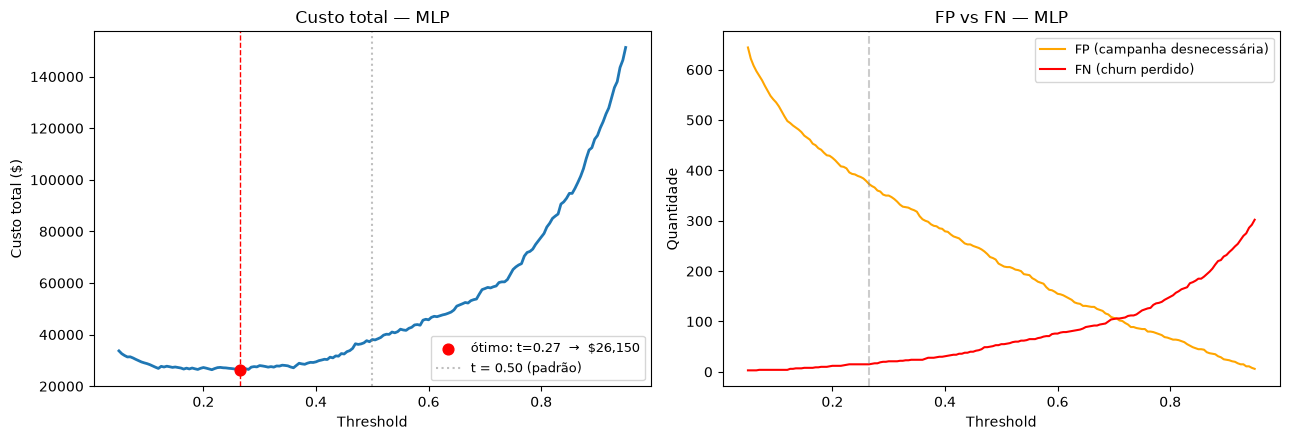

  → MLP: threshold ótimo = 0.27, custo = $26,150



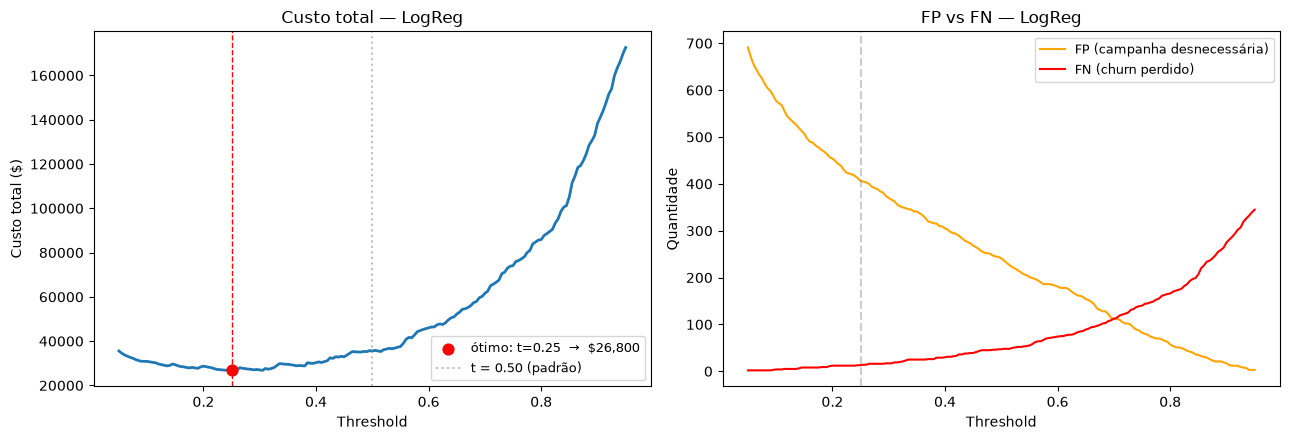

  → LogReg: threshold ótimo = 0.25, custo = $26,800



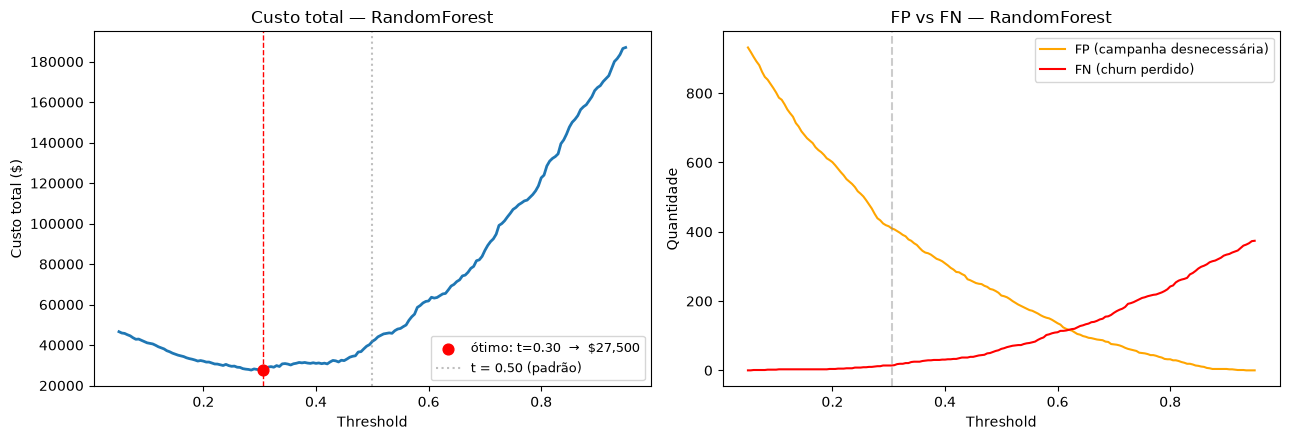

  → RandomForest: threshold ótimo = 0.30, custo = $27,500



,t_otimo,custo_otimo,recall_otimo,prec_otimo,f1_otimo,custo_t05,recall_t05,prec_t05
modelo,,,,,,,,
MLP,0.265,26150,0.9599,0.4904,0.6492,38100,0.8529,0.6008
LogReg,0.250,26800,0.9652,0.4707,0.6328,35550,0.8743,0.5757
RandomForest,0.305,27500,0.9626,0.4675,0.6294,41800,0.8342,0.5909


In [19]:
# ── Probas no teste (todos no mesmo X_tr/X_te → comparação justa) ─

lr = LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced")
lr.fit(X_tr, y_tr)
proba_lr = lr.predict_proba(X_te)[:, 1]

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                             class_weight="balanced", random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)
proba_rf = rf.predict_proba(X_te)[:, 1]

# MLP — ajuste a config para o melhor modelo
model_custo, _ = rodar_experimento(batch=128, log_mlflow=False)
model_custo.eval()
with torch.no_grad():
    proba_mlp = torch.sigmoid(model_custo(Xte_t)).cpu().numpy().ravel()

y_true = y_te.values.ravel()

# ── Gráficos por modelo ───────────────────────────────────────────
for nome, proba in [("MLP", proba_mlp), ("LogReg", proba_lr), ("RandomForest", proba_rf)]:
    df_c = custo_por_threshold(y_true, proba)
    t, c = plotar_custo(df_c, nome)
    print(f"  → {nome}: threshold ótimo = {t:.2f}, custo = ${c:,.0f}\n")

# ── Tabela comparativa: threshold ótimo vs padrão (0.5) ───────────
modelos_proba = {"MLP": proba_mlp, "LogReg": proba_lr, "RandomForest": proba_rf}
display(comparar_custos(modelos_proba, y_true))

## 10. Conclusões e próximos passos

**Conclusões**

A validação cruzada estratificada (Seção 7, 5 folds sobre o dev set) estabeleceu a performance-base dos modelos antes de qualquer exploração de hiperparâmetros. Os desvios-padrão de PR-AUC entre folds são baixos, confirmando que os resultados não dependem de uma partição sortuda e que as estimativas são estáveis.

A MLP com arquitetura `[64, 32]`, dropout de 0.3 e `BCEWithLogitsLoss` com `pos_weight` atinge PR-AUC de **0,781** no hold-out (melhor config: batch=128), competitiva com a Regressão Logística (**0,764**) e o Random Forest (**0,748**). Os três modelos reais operam na mesma faixa (~0,75–0,78), confirmando que para este dataset tabular de ~7 mil linhas o sinal preditivo está nas features — especialmente `tenure` e variáveis de contrato — e não na complexidade do modelo. As médias do CV são consistentes com os valores do hold-out, reforçando a confiança nas estimativas.

A métrica `dif_pr_auc` (diferença entre PR-AUC de treino e teste) revelou-se o melhor indicador de overfitting, tanto no hold-out quanto no CV: o Random Forest decora mais (~0,09) que a MLP (~0,03–0,06) e a Regressão Logística (~0,01). A métrica de overfitting baseada em acurácia chega a inverter esse ranking, reforçando que não é confiável em dados desbalanceados.

A análise de custo (Seção 9) mostrou que o threshold operacional importa mais que a escolha do modelo. Com uma razão FN/FP de 10:1, o threshold ótimo cai para ~0,27 — reduzindo o custo total em ~35–40% em relação ao padrão de 0,5. No ponto ótimo, a MLP tem leve vantagem ($26.150 vs $27.500 do RF), mas a diferença entre modelos (~5%) é pequena frente ao ganho de ajustar o threshold (~35%).

**Limitações**

O dataset é um snapshot transversal — sem dados longitudinais, não é possível modelar trajetórias de comportamento. Boa parte do sinal preditivo vem de `tenure` e variáveis correlatas, o que torna o modelo sensível a drift nessa distribuição. O dataset também não registra campanhas de retenção: o modelo prevê churn *sem intervenção*, não *apesar* dela. Por fim, `SatisfactionScore` foi confirmada como data leakage (PR-AUC salta para ~0,98 ao incluí-la) e excluída de todos os modelos.

**Próximos passos (Etapas 3 e 4)**

Refatorar os notebooks para módulos em `src/churn/` com pipeline reprodutível (sklearn + transformadores custom), testes pytest e API FastAPI (`/predict`, `/health`). A Etapa 4 inclui Model Card, documento de arquitetura de deploy (batch vs real-time), plano de monitoramento e vídeo STAR.